# AdTech Campaign Performance & A/B Testing Analysis
### Business Analyst Portfolio Project — Nasim Maleki

An ad-tech company ran 40 user-acquisition campaigns across 10 markets in 2024. This analysis supports two business decisions: **how to reallocate the UA budget** for maximum installs, and **whether to adopt a trialled new ad format**.

This notebook follows a full business analyst workflow: business framing, requirements, data governance, analysis, statistical testing, and quantified recommendations, not just exploratory data analysis.

---

## Executive Summary

**Headline findings:**
- Only **32.8% of the EUR 433k budget was actually spent**, 29 of 40 campaigns under utilised their allocation, while one campaign overspent to 193%.
- The funnel converts at **6.1% view-to-install**, with the biggest drop (67.7%) at the **View to Click** stage.
- The strongest audience is **18-44 in the USA and Germany**; gender has no effect on conversion.
- Performance is **seasonal**: install rate falls from ~23% in spring to ~13% in summer.
- The new ad format's CTR lift (12.5% to 14.0%) is **not statistically significant** (p = 0.20) and the test was ~8x underpowered.

**Bottom line:** Significant install growth is available by deploying idle budget into proven efficient campaigns and high converting segments. The ad-format switch should wait for a properly powered test.

---

## 1. Business Problem & Project Brief
**BA Category: Business Context**

### The Decisions At Stake
1. **Budget reallocation**: how should the next period's UA budget be distributed across campaigns and segments to maximise installs per euro?
2. **Ad-format switch**: should the company roll out the new ad format, keep testing, or abandon it?

### Scope
**In scope:** 2024 campaign events (views, clicks, installs), user demographics, campaign budgets and cost-per-install, the A/B test on ad format.

**Out of scope:** creative-level quality, organic installs, post-install retention/LTV, auction mechanics.

### Success Criteria
Rank campaigns by true efficiency, identify the highest-converting segments, give a clear evidence-backed verdict on the ad format, and translate findings into quantified budget actions.

## 2. Stakeholder Analysis
**BA Category: Stakeholder Analysis**

| Stakeholder | Decision they own | Primary interest | Influence |
|---|---|---|---|
| Marketing / UA team | Budget allocation | Maximise installs per euro | High |
| Product / Growth | Adopt the new ad format | Better UX and conversion | High |
| Finance | Approves total budget | ROI and spend discipline | Medium |
| Data / Analytics | Pipeline and definitions | Trustworthy, reproducible numbers | Medium |

Each finding in this project is addressed to a specific decision owner, the analysis is built around who consumes the output and what they will do with it.

## 3. Requirements & Business Questions
**BA Category: Requirements Analysis**

### Functional Requirements
- FR1: Rank campaigns by efficiency, not just spend
- FR2: Report budget utilisation per campaign
- FR3: Quantify the Views to Clicks to Installs funnel
- FR4: Identify highest/lowest-converting segments
- FR5: Show monthly performance across 2024
- FR6: Deliver a statistically valid verdict on the ad format
- FR7: Translate findings into quantified actions

### Business Questions
1. Which campaigns performed best, and how efficiently was budget spent?
2. How much of each campaign's allocated budget was actually used?
3. Where in the funnel do we lose the most users?
4. Which segments convert most efficiently?
5. Is there seasonality across the year?
6. Is the A/B sampling representative?
7. Is the new format's CTR lift statistically significant?
8. Was the experiment powerful enough, what should we do?

## 4. Data Requirements & Data Dictionary
**BA Category: Data Requirements**

| Table | Grain (one row =) |
|---|---|
| Campaigns | one campaign |
| CampaignViews | one ad view |
| CampaignClicks | one ad click |
| CampaignInstalls | one app install |
| Users | one user |
| Control / Target Group | one user in an A/B arm |

**Key fields:** event tables carry `View_id`/`Click_id`/`Install_id`, plus `User_id`, `Campaign_id`, `timestamp`. Campaigns carry `TotalBudget`, `CostPerInstall`, `Category`, `Start_Date`, `End_Date`. Users carry `AgeGroup`, `Gender`, `Country`. A/B tables add `Age`, `ARPU($)`.

### Setup — Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.graph_objects as go
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#2e3350", "axes.labelcolor": "#e8eaf0",
    "xtick.color": "#7b82a0", "ytick.color": "#7b82a0", "text.color": "#e8eaf0",
    "grid.color": "#2e3350", "grid.linestyle": "--", "grid.alpha": 0.4,
    "figure.figsize": (12, 5),
})
os.makedirs("charts", exist_ok=True)

In [2]:
# Load all 7 tables
FILE = "/content/database_extended.xlsx"
campaigns = pd.read_excel(FILE, sheet_name="Section1. Campaigns")
views = pd.read_excel(FILE, sheet_name="Section1. CampaignViews")
clicks = pd.read_excel(FILE, sheet_name="Section1. CampaignClicks")
installs = pd.read_excel(FILE, sheet_name="Section1. CampaignInstalls")
users = pd.read_excel(FILE, sheet_name="Section1. Users")
control = pd.read_excel(FILE, sheet_name="Section2. Control Group")
target = pd.read_excel(FILE, sheet_name="Section2. Target Group")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# turning timestamps into datetime format
for df in [views, clicks, installs]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
# the number of rows in every table
print("Rows:", {n: len(d) for n, d in
      [("campaigns",campaigns),("views",views),("clicks",clicks),("installs",installs),("users",users)]})

Rows: {'campaigns': 40, 'views': 120128, 'clicks': 38808, 'installs': 7285, 'users': 3000}


## 5. Business Rules & KPI Definitions
**BA Category: Business Rules & Definitions**

| Metric | Formula | Tells us |
|---|---|---|
| CTR | clicks / views | How compelling the ad is at earning a click |
| Install Rate | installs / clicks | How well a click converts to install |
| IPM | 1000 x installs / views | Installs per thousand views (size-normalised) |
| Cost Per Install | spend / installs | Efficiency in euros per install |
| Budget Utilisation | spend / TotalBudget | Share of allocated budget used |

**Business rules:** only 2024-timestamped events are valid; a valid event needs a non-null `User_id` and a `Campaign_id` present in Campaigns; installs use single-touch (last-campaign) attribution.

> **IPM is the key choice**, comparing campaigns on raw installs is unfair because bigger campaigns naturally get more installs. IPM normalises for that. So by deiding the number of installs to the number of views, we are nutralize the effect of views number in each campaign and because these numbers are too low we are multiplying it by 1000.

## 6. Data Quality Assessment & Cleaning
**BA Category: Data Quality & Governance**

Before any analysis, the raw data is audited for nulls, duplicate event IDs, orphan events (no parent campaign), and out-of-range timestamps. Each issue is documented and handled with a recorded rationale.

In [6]:
# AUDIT
print("NULL VALUES")
for name, df in [("Campaigns",campaigns),("Views",views),("Clicks",clicks),("Installs",installs),("Users",users)]:
    print(f"  {name}: {df.isnull().sum().sum()}") #how many nulls in the whole dataframe? and our data is a 2D table

print("\n DUPLICATE EVENT IDs")
print(f" Views: {views['View_id'].duplicated().sum()}")
print(f" Clicks: {clicks['Click_id'].duplicated().sum()}")
print(f" Installs: {installs['Install_id'].duplicated().sum()}")

valid_campaigns = set(campaigns["Campaign_id"])
print("\n ORPHAN EVENTS (campaign not in Campaigns)")
print(f" Orphan clicks: {(~clicks['Campaign_id'].isin(valid_campaigns)).sum()}")

print("\n OUT OF RANGE TIMESTAMPS (not 2024)")
oor = views[(views['timestamp'] < '2024-01-01') | (views['timestamp'] > '2024-12-31 23:59:59')]
print(f" Views outside 2024: {len(oor)}")

NULL VALUES
  Campaigns: 0
  Views: 60
  Clicks: 0
  Installs: 0
  Users: 0

 DUPLICATE EVENT IDs
 Views: 150
 Clicks: 80
 Installs: 0

 ORPHAN EVENTS (campaign not in Campaigns)
 Orphan clicks: 80

 OUT OF RANGE TIMESTAMPS (not 2024)
 Views outside 2024: 40


In [7]:
# Cleaning data
views_clean= views.drop_duplicates(subset=["View_id"])
views_clean= views_clean.dropna(subset=["User_id"])
views_clean= views_clean[(views_clean["timestamp"] >= "2024-01-01") &
                          (views_clean["timestamp"] <= "2024-12-31 23:59:59")]
clicks_clean= clicks.drop_duplicates(subset=["Click_id"])
clicks_clean= clicks_clean[clicks_clean["Campaign_id"].isin(valid_campaigns)]

installs= installs[installs["Campaign_id"].isin(valid_campaigns)]
print(f"Views: {len(views):,} -> {len(views_clean):,}")
print(f"Clicks: {len(clicks):,} -> {len(clicks_clean):,}")
print(f"Installs: {len(installs):,} (no issues)")

# Why remove not impute: these are event-log integrity problems
# (a duplicate event didn't happen twice), not missing measurements.

Views: 120,128 -> 119,878
Clicks: 38,808 -> 38,728
Installs: 7,285 (no issues)


## 7. Campaign Performance Analysis (SQL)
**BA Category: Analysis & Insight**

Using SQL with CTEs, count views/clicks/installs per campaign and join back to budgets. Two business-critical columns added beyond the original: **budget utilisation** and **efficiency tiering** by cost per install.

In [8]:
conn = sqlite3.connect(":memory:")
campaigns.to_sql("Campaigns", conn, index=False, if_exists="replace")
views_clean.to_sql("CampaignViews", conn, index=False, if_exists="replace")
clicks_clean.to_sql("CampaignClicks", conn, index=False, if_exists="replace")
installs.to_sql("CampaignInstalls", conn, index=False, if_exists="replace")
users.to_sql("Users", conn, index=False, if_exists="replace")

query = '''
WITH V AS
(SELECT Campaign_id, COUNT(DISTINCT View_id) vc
 FROM CampaignViews
 GROUP BY Campaign_id),
 C AS
 (SELECT Campaign_id, COUNT(DISTINCT Click_id) cc
 FROM CampaignClicks
 GROUP BY Campaign_id),
 I AS
 (SELECT Campaign_id, COUNT(DISTINCT Install_id) ic
  FROM CampaignInstalls
  GROUP BY Campaign_id)
SELECT cp.Campaign_Name, cp.Category, cp.TotalBudget,
  IFNULL(V.vc,0) views,
  IFNULL(C.cc,0) clicks,
  IFNULL(I.ic,0) installs,
  cp.CostPerInstall*IFNULL(I.ic,0) AS spend,
  ROUND(100.0*cp.CostPerInstall*IFNULL(I.ic,0)/cp.TotalBudget,1) AS budget_used_pct,
  ROUND(100.0*IFNULL(C.cc,0)/NULLIF(V.vc,0),2) AS ctr,
  ROUND(100.0*IFNULL(I.ic,0)/NULLIF(C.cc,0),2) AS install_rate,
  CASE WHEN IFNULL(I.ic,0)>0
    THEN cp.CostPerInstall
    END AS cost_per_install
FROM Campaigns cp
LEFT JOIN V ON V.Campaign_id=cp.Campaign_id
LEFT JOIN C ON C.Campaign_id=cp.Campaign_id
LEFT JOIN I ON I.Campaign_id=cp.Campaign_id
ORDER BY spend DESC'''
perf= pd.read_sql_query(query, conn)
perf.head(8)

,Campaign_Name,Category,TotalBudget,views,clicks,installs,spend,budget_used_pct,ctr,install_rate,cost_per_install
0,Campaign_7,Travel,12000,7264,3269,890,23140,192.8,45.00,27.23,26
1,Campaign_25,Education,20000,6680,2380,501,10020,50.1,35.63,21.05,20
2,Campaign_33,Health,12000,6824,2491,498,6972,58.1,36.50,19.99,14
3,Campaign_27,Travel,9000,2348,1075,240,6720,74.7,45.78,22.33,28
4,Campaign_31,Social,7000,2658,1178,279,6696,95.7,44.32,23.68,24
5,Campaign_21,Finance,20000,3303,1362,321,6420,32.1,41.24,23.57,20
6,Campaign_2,Gaming,5000,2091,932,224,6048,121.0,44.57,24.03,27
7,Campaign_8,Finance,12000,3965,1691,453,5889,49.1,42.65,26.79,13


In [9]:
total_spend= perf["spend"].sum();
total_budget = perf["TotalBudget"].sum()
print(f"Total spend: EUR {total_spend:,.0f}")
print(f"Total budget: EUR {total_budget:,.0f}")
print(f"Budget utilised: {total_spend/total_budget*100:.1f}%")
print(f"Campaigns under 50% budget: {(perf['budget_used_pct']<50).sum()} of {len(perf)}")

eff= perf[perf["cost_per_install"].notna()].sort_values("cost_per_install")
print(f"\nMost efficient: {list(eff.head(3)['Campaign_Name'])}")
print(f"Least efficient: {list(eff.tail(3)['Campaign_Name'])}")

Total spend: EUR 142,075
Total budget: EUR 433,000
Budget utilised: 32.8%
Campaigns under 50% budget: 29 of 40

Most efficient: ['Campaign_13', 'Campaign_4', 'Campaign_22']
Least efficient: ['Campaign_14', 'Campaign_29', 'Campaign_10']


**Finding:** Only **32.8%** of allocated budget was spent, with **29 of 40 campaigns** under 50% utilisation, while Campaign_7 overspent to 193%. The biggest lever is redeploying idle budget into the proven-efficient campaigns.

## 8. Conversion Funnel Analysis
**BA Category: Analysis & Insight**

Quantify the Views to Clicks to Installs cascade and locate the biggest drop-off.

In [10]:

total_views = perf["views"].sum()
total_clicks = perf["clicks"].sum()
total_installs= perf["installs"].sum()
views_lost = total_views - total_clicks    # viewed but never clicked
clicks_lost= total_clicks - total_installs  # clicked but never installed

fig= go.Figure(go.Waterfall(
    name = "Funnel",
    orientation = "v",
    measure = ["absolute", "relative", "total", "relative", "total"],
    x = ["Views", "Lost (no click)", "Clicks", "Lost (no install)", "Installs"],
    y = [total_views, -views_lost, total_clicks, -clicks_lost, total_installs],
    connector = {"line": {"color": "#7b82a0"}},
    decreasing = {"marker": {"color": "#ef4444"}},
    increasing = {"marker": {"color": "#14b8a6"}},
    totals     = {"marker": {"color": "#6366f1"}},
))

fig.update_layout(
    title = "Conversion Funnel: Views → Clicks → Installs",
    showlegend = False,
)
fig.show()

In [11]:
print(total_views, total_clicks, total_installs)

119878 38728 7285


In [12]:
import plotly.graph_objects as go
labels = ["Views", "Clicks", "Installs", "No click", "No install"]
# index:   0         1          2           3           4

fig = go.Figure(go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=20,
        color=["#6366f1", "#14b8a6", "#22c55e", "#3a3f5c", "#3a3f5c"],
    ),
    link=dict(
        source=[0, 0, 1, 1],
        target=[1, 3, 2, 4],
        value=[total_clicks, views_lost, total_installs, clicks_lost],
        color=["rgba(20,184,166,0.4)", "rgba(120,130,160,0.25)",
               "rgba(34,197,94,0.4)",  "rgba(120,130,160,0.25)"],
    )
))

fig = fig.update_layout(
    title="Conversion Funnel: Views → Clicks → Installs",
    font=dict(size=13, color="#e8eaf0"),
    paper_bgcolor="#0f1117"
)
fig.show()

In [13]:
!pip install kaleido==0.2.1

Views: 119878  (100.0%)
Clicks: 38728  (32.3% of views)
Installs: 7285  (18.8% of clicks)

Overall view-to-install: 6.08%
Largest absolute drop: View->Click (81,150 users lost)


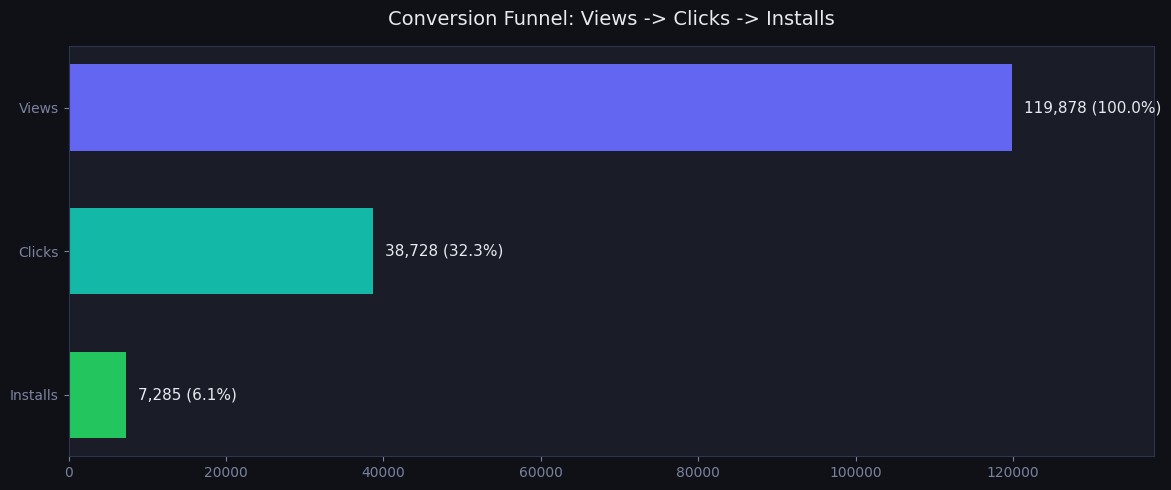

In [15]:
tv, tc, ti = len(views_clean), len(clicks_clean), len(installs)
print(f"Views: {tv}  (100.0%)")
print(f"Clicks: {tc}  ({tc/tv*100:.1f}% of views)")
print(f"Installs: {ti}  ({ti/tc*100:.1f}% of clicks)")
print(f"\nOverall view-to-install: {ti/tv*100:.2f}%")
print(f"Largest absolute drop: View->Click ({tv-tc:,} users lost)")

fig, ax = plt.subplots()
stages=["Views","Clicks","Installs"]; vals=[tv,tc,ti]
ax.barh(stages, vals, color=["#6366f1","#14b8a6","#22c55e"], height=0.6)
for i,v in enumerate(vals):
    ax.text(v+1500, i, f"{v:,} ({v/vals[0]*100:.1f}%)", va="center", fontsize=11)
ax.set_title("Conversion Funnel: Views -> Clicks -> Installs", fontsize=14, pad=15)
ax.invert_yaxis(); ax.set_xlim(0, tv*1.15)
plt.tight_layout(); plt.savefig("charts/funnel.png", dpi=150, bbox_inches="tight"); plt.show()

**Finding:** The largest absolute drop is at **View to Click** (67.7% lost). Although Click to Install has a lower *rate*, the View to Click stage loses far more people in raw numbers, making it the highest-leverage place to improve.

## 9. Segment Performance Analysis (IPM)
**BA Category: Analysis & Insight**

IPM (1000 x installs / views) per age x gender x country segment, to find the most efficient audiences.

In [16]:
seg_query = '''
WITH Views AS (
  SELECT CV.Campaign_id, U.AgeGroup, U.Gender, U.Country,
         COUNT(DISTINCT CV.View_id) AS ViewCount
  FROM CampaignViews CV
  LEFT JOIN Users U ON CV.User_id=U.User_id
  GROUP BY CV.Campaign_id, U.AgeGroup, U.Gender, U.Country),
Installs AS (
  SELECT CI.Campaign_id, U.AgeGroup, U.Gender, U.Country,
         COUNT(DISTINCT CI.Install_id) AS InstallCount
  FROM CampaignInstalls CI
  LEFT JOIN Users U ON CI.User_id=U.User_id
  GROUP BY CI.Campaign_id, U.AgeGroup, U.Gender, U.Country)
SELECT V.AgeGroup AS "Age-Group", V.Gender, V.Country,
       SUM(V.ViewCount) AS Views,
       SUM(IFNULL(I.InstallCount,0)) AS Installs,
       CASE WHEN SUM(V.ViewCount)>0
            THEN 1000.0*SUM(IFNULL(I.InstallCount,0))/SUM(V.ViewCount) ELSE 0 END AS IPM
FROM Views V
LEFT JOIN Installs I ON V.Campaign_id=I.Campaign_id AND V.AgeGroup=I.AgeGroup
     AND V.Gender=I.Gender AND V.Country=I.Country
GROUP BY V.AgeGroup, V.Gender, V.Country'''
seg= pd.read_sql_query(seg_query, conn)
seg= seg.dropna(subset=["Age-Group"])
seg

,Age-Group,Gender,Country,Views,Installs,IPM
0,18-24,Female,Austria,482,15,31.120332
1,18-24,Female,Canada,674,38,56.379822
2,18-24,Female,France,1423,74,52.002811
3,18-24,Female,Germany,4085,328,80.293758
4,18-24,Female,Italy,658,27,41.033435
...,...,...,...,...,...,...
145,65+,Other,Austria,14,0,0.000000
146,65+,Other,Germany,22,2,90.909091
147,65+,Other,Netherlands,3,0,0.000000
148,65+,Other,UK,16,0,0.000000


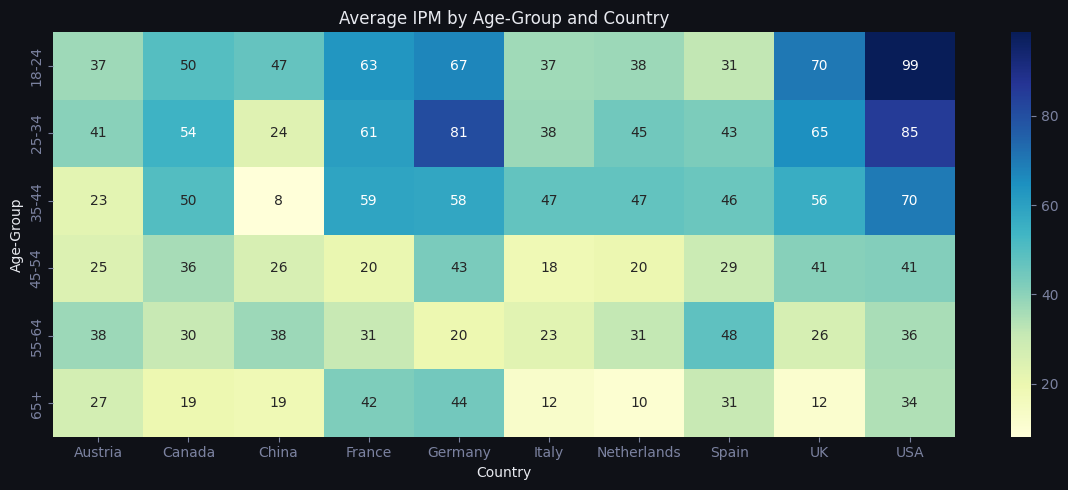

Gender
Female    40.0
Male      40.6
Other     44.4
Name: IPM, dtype: float64


In [17]:
# Heatmap: average IPM by Age-Group x Country
pivot = seg.groupby(["Age-Group","Country"])["IPM"].mean().unstack()
plt.figure(figsize=(12,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average IPM by Age-Group and Country")
plt.tight_layout(); plt.savefig("charts/segment_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(seg.groupby("Gender")["IPM"].mean().round(1))

**Finding:** Strongest segments are **18-44 in USA and Germany**; weakest are Italy and Austria. **Gender has no meaningful effect** on IPM, a result reused later to argue the A/B test's gender imbalance is low-risk.

## 10. Time Trends & Seasonality
**BA Category: Analysis & Insight**

Monthly install volume and install *rate* across 2024, to detect seasonality.

In [18]:
for df in [views_clean, clicks_clean, installs]:
    df["month"] = df["timestamp"].dt.to_period("M").astype(str)

trend = pd.DataFrame({
    "views": views_clean.groupby("month").size(),
    "clicks": clicks_clean.groupby("month").size(),
    "installs": installs.groupby("month").size(),
}).fillna(0)
trend = trend[trend.index.str.startswith("2024")]
trend["install_rate"] = (trend["installs"]/trend["clicks"]*100).round(1)
print(trend)

spring = trend.loc[["2024-03","2024-04","2024-05"],"installs"].mean()
summer = trend.loc[["2024-06","2024-07","2024-08"],"installs"].mean()
print(f"\nSpring avg: {spring:,.0f}  Summer avg: {summer:,.0f}  Dip: {(summer-spring)/spring*100:.1f}%")

         views  clicks  installs  install_rate
month                                         
2024-01   2374     750       129          17.2
2024-02   7400    2494       486          19.5
2024-03  11251    4379      1008          23.0
2024-04  11700    4671      1071          22.9
2024-05  13756    5435      1144          21.0
2024-06  16369    4631       743          16.0
2024-07  12735    3065       386          12.6
2024-08  14531    3389       439          13.0
2024-09  14572    4158       700          16.8
2024-10   9712    3392       671          19.8
2024-11   4521    1901       403          21.2
2024-12    957     463       105          22.7

Spring avg: 1,074  Summer avg: 523  Dip: -51.3%


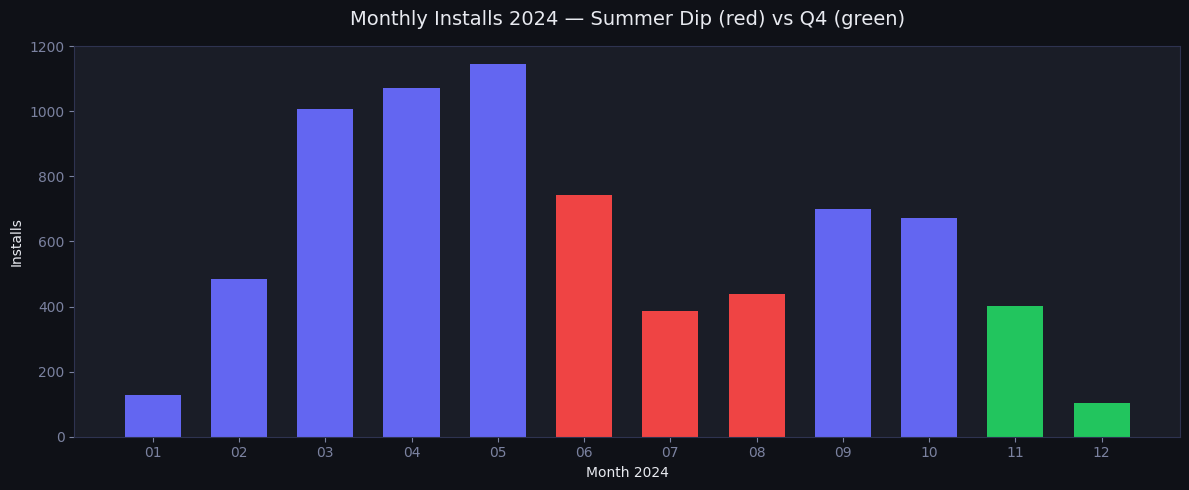

In [19]:
months = trend.index.tolist()
colors = ["#ef4444" if m[5:] in ["06","07","08"]
          else "#22c55e" if m[5:] in ["11","12"] else "#6366f1" for m in months]
fig, ax = plt.subplots()
ax.bar(range(len(months)), trend["installs"].values, color=colors, width=0.65)
ax.set_xticks(range(len(months))); ax.set_xticklabels([m[5:] for m in months])
ax.set_title("Monthly Installs 2024 — Summer Dip (red) vs Q4 (green)", fontsize=14, pad=15)
ax.set_xlabel("Month 2024"); ax.set_ylabel("Installs")
plt.tight_layout(); plt.savefig("charts/seasonality.png", dpi=150, bbox_inches="tight"); plt.show()

**Finding:** Install rate falls from **~23% in spring to ~13% in summer**: summer traffic converts worse, not just lower volume. Budget concentrated in Jun-Aug works harder for less return.

> Honest alert: very low Jan/Dec figures are partly because fewer campaigns are live at the year's edges, not pure seasonality. The defensible story is the Jun-Aug rate drop vs the Mar-May peak.

## 11. A/B Test: Sampling & Validity Check
**BA Category: Experimentation**

Before trusting any result, validate that the experiment's sampling is sound: check for user overlap and compare distributions across the two arms.

In [20]:
overlap = set(control["User_id"]).intersection(set(target["User_id"]))
print(f"User overlap between arms: {len(overlap)} (should be 0)")

from scipy.stats import chi2_contingency
gender_table= pd.crosstab(
    pd.concat([control["Gender"], target["Gender"]]),
    ["Control"]*len(control) + ["Target"]*len(target))
chi2, p_gender, _, _ = chi2_contingency(gender_table)
print(f"Gender distribution chi-square p-value: {p_gender:.4f}")

print(f"\nARPU mean, Control: {control['ARPU($)'].mean():.2f}, Target: {target['ARPU($)'].mean():.2f}")
print(f"Age mean, Control: {control['Age'].mean():.1f}, Target: {target['Age'].mean():.1f}")

User overlap between arms: 0 (should be 0)
Gender distribution chi-square p-value: 0.1831

ARPU mean, Control: 19.46, Target: 21.30
Age mean, Control: 43.6, Target: 44.0


**Finding:** No user overlap (clean assignment). Age is balanced. But **ARPU is higher in the target arm** and country/gender show imbalance, real confounds. The 20/80 split is acceptable on risk grounds, but results must be read with caution. Validating the experiment *before* reading results is the senior move here.

## 12. A/B Test: Significance & Power Analysis
**BA Category: Experimentation**

The test ran two weeks. Control (old format): 4,000 impressions, 500 clicks, CTR 12.5%. Target (new format): 1,000 impressions, 140 clicks, CTR 14.0%. Is the 1.5pp lift real?

In [21]:
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

clicks_ab = np.array([500, 140]); views_ab = np.array([4000, 1000])
z, p = proportions_ztest(count=clicks_ab, nobs=views_ab)
print(f"Z-statistic: {z:.4f}")
print(f"P-value    : {p:.4f}")
print("Significant at 0.05?", "YES" if p < 0.05 else "NO")

Z-statistic: -1.2699
P-value    : 0.2041
Significant at 0.05? NO


The standard threshold is 5% (p < 0.05). this number (20%) chance this is just noise, we cannot conclude the new format is better. The result is not significant.The test was too small to detect a real effect even if one exists.

In [22]:
# Power analysis: how big a sample would we have needed?
effect = proportion_effectsize(0.140, 0.125)
required_n = NormalIndPower().solve_power(
    effect_size=effect, alpha=0.05, power=0.80, alternative="two-sided")
print(f"Effect size: {effect:.4f}")
print(f"Required sample per group: {required_n:,.0f}")
print(f"Actual target group: 1,000  ->  ~{required_n/1000:.0f}x too small")

Effect size: 0.0443
Required sample per group: 8,013
Actual target group: 1,000  ->  ~8x too small


**Conclusion:** The lift is **not statistically significant** (p = 0.20), and the test was **around 8x underpowered**, it never had enough data to detect an effect of this size. **Do not switch formats yet.** Extend the test to 8,000 impressions per arm; if the lift persists, it would then be significant.

## 13. Recommendations & Decision Memo
**BA Category: Recommendations & Decision**

Each recommendation links to evidence and follows what / why / expected outcome.

**1. Deploy unused budget into proven-efficient campaigns.** Only 32.8% of budget was spent. Redirect idle budget to the lowest-CPI campaigns -> more installs at the same total budget.

**2. Cap the overspending campaign.** Campaign_7 spent 193% of budget at high CPI -> cap or renegotiate -> less wasted spend.

**3. Concentrate targeting on 18-44 USA/Germany.** Highest IPM segments -> more installs per thousand views.

**4. Drop gender-based targeting.** IPM flat across genders -> simpler campaigns, no performance loss.

**5. Shift budget away from the summer trough.** Install rate 23% (spring) vs 13% (summer) -> spend when users convert.

**6. Improve the View to Click stage.** 67.7% of users lost here -> a 1pp CTR lift ~= +1,200 clicks and ~225 installs per period.

**7. Do not switch ad format yet.** Lift not significant (p=0.20), test 8x underpowered -> extend to ~8,000 impressions/arm before deciding.

## 14. Conclusion

This project followed a complete business analyst workflow: framing the business problem, mapping stakeholders, defining requirements and metrics, governing data quality, then analysing campaign efficiency, the conversion funnel, audience segments, and seasonality, before applying rigorous A/B testing and translating everything into quantified recommendations.

**The single most valuable insight:** the company has substantial idle budget (only 32.8% utilised) that, redeployed into proven efficient campaigns and high converting segments, would drive meaningful install growth with no increase in total spend.

---
*Nasim Maleki · Business Analyst · Bremen, Germany*